In [3]:
import pandas as pd
import requests
import numpy as np
import datetime

In [1]:
def fetch_fred_series(series_id, api_key):
    url = "https://api.stlouisfed.org/fred/series/observations"
    params = {
        "series_id": series_id,
        "api_key": api_key,
        "file_type": "json",
    }
    response = requests.get(url, params=params)
    response.raise_for_status()
    observations = response.json()["observations"]

    df = pd.DataFrame(observations)[["date", "value"]]
    df["date"] = pd.to_datetime(df["date"])
    df["value"] = pd.to_numeric(df["value"], errors="coerce")  # "." -> NaN
    return df

In [4]:
with open("API_KEY.txt", "r") as f:
    FRED_API_KEY = f.read().strip()

oil_data = fetch_fred_series("DCOILWTICO", FRED_API_KEY)
cpi_data = fetch_fred_series("CPIAUCSL", FRED_API_KEY)   

from datetime import datetime

start = datetime(1980, 1, 1)
end = datetime(2023, 3, 1)

oil_data = oil_data[(oil_data["date"] >= start) & (oil_data["date"] <= end)]
cpi_data = cpi_data[(cpi_data["date"] >= start) & (cpi_data["date"] <= end)]

oil_data = oil_data.dropna(subset=["value"])

How to do vol calculation:

Take the log returns of oil every day, then get the standard deviation of a month's worth of log returns. This returns monthly volatility, but you can turn it into a yearly metric (the standard for finance) by multiplying by sqrt(252). 252 is significiant as the number of trading days in a year.

In [5]:
oil_data = oil_data.sort_values("date")
oil_data["log_return"] = np.log(oil_data["value"]).diff()

c:\Users\henke\AppData\Local\Programs\Python\Python310\lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [14]:
monthly_vol = (
    oil_data
    .set_index("date")["log_return"]
    .groupby(pd.Grouper(freq="ME"))
    .std()
    .mul(np.sqrt(252)) #sqrt here is for annualized volatility
    .rename("oil_vol_annualized")
    .to_frame()
)

In [7]:
cpi_monthly = (
    cpi_data
    .sort_values("date")
    .set_index("date")["value"]
    .resample("ME")
    .last()
    .rename("cpi")
    .to_frame()
)

Adding the month over month to the data, which will be used for analysis. Creates an apples to apples comparison.

In [27]:
cpi_monthly["cpi_mom_annualized"] = (
    (1 + cpi_monthly["cpi"].pct_change()) ** 12 - 1
) * 100

In [29]:
merged_data = monthly_vol.join(cpi_monthly, how="inner").dropna()

In [30]:
merged_data

,oil_vol_annualized,cpi,cpi_yoy,cpi_mom_annualized
date,,,,
1986-01-31,0.555074,109.900,3.973510,4.472714
1986-02-28,0.844474,109.700,3.198495,-2.162078
1986-03-31,1.095560,109.100,2.153558,-6.369471
1986-04-30,0.908891,108.700,1.588785,-4.311990
1986-05-31,0.683020,109.000,1.679104,3.362605
...,...,...,...,...
2022-10-31,0.393499,298.007,7.758814,6.924196
2022-11-30,0.423514,298.786,7.122856,3.182333
2022-12-31,0.344757,298.832,6.404600,0.184904


Now, we have a unified data set cleaned from null values. The data has CPI year over year and annualized volatility for a sequence of 446 months. With this, we can do a simple one-liner to get correlation between the two numbers.

In [32]:
merged_data[["oil_vol_annualized", "cpi_mom_annualized"]].corr()

,oil_vol_annualized,cpi_mom_annualized
oil_vol_annualized,1.000000,-0.236624
cpi_mom_annualized,-0.236624,1.000000


Here, we see that the correlation is -0.236 between the two numbers. A number that close to zero indicates that oil volatility and inflation have a weak relationship. However, this may be different if we introduce lag. The theory here is that volatility in oil takes time to affect prices. It will be difficult to identify the correct lag - so we will go across a range of several months to see.

In [39]:
lags = range(1, 13)  # oil vol leading CPI by up to 12 months, and vice versa
results = []

for k in lags:
    shifted = merged_data["oil_vol_annualized"].shift(k)
    r = shifted.corr(merged_data["cpi_mom_annualized"])
    results.append({"lag": k, "corr": r})

lag_corr = pd.DataFrame(results)

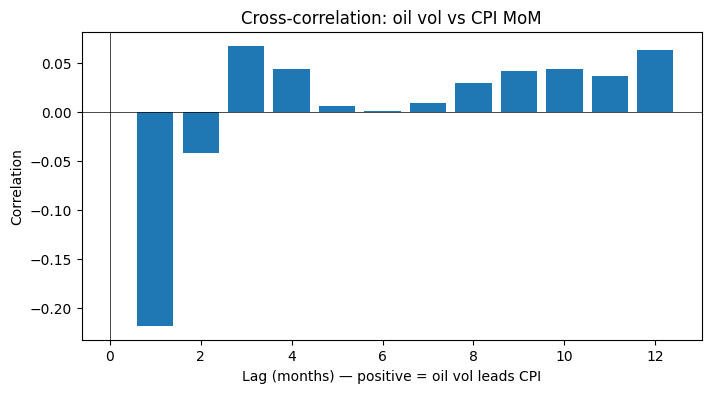

In [40]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
plt.bar(lag_corr["lag"], lag_corr["corr"])
plt.axvline(0, color="black", linewidth=0.5)
plt.axhline(0, color="black", linewidth=0.5)
plt.xlabel("Lag (months) — positive = oil vol leads CPI")
plt.ylabel("Correlation")
plt.title("Cross-correlation: oil vol vs CPI MoM")
plt.show()